In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("pandas_big_project_orders.csv")

In [3]:
df.head()
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 18022 entries, 0 to 18021
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   order_id                   18022 non-null  str    
 1   customer_id                18022 non-null  str    
 2   order_date                 18022 non-null  str    
 3   city                       17844 non-null  str    
 4   gender                     17523 non-null  str    
 5   acquisition_channel        18022 non-null  str    
 6   device                     17921 non-null  str    
 7   payment_method             17872 non-null  str    
 8   shipping_method            18022 non-null  str    
 9   shipping_fee               18022 non-null  int64  
 10  tax_rate                   18022 non-null  float64
 11  order_status               18022 non-null  str    
 12  product_id                 18022 non-null  str    
 13  product_category           18022 non-null  str    
 14  p

,shipping_fee,tax_rate,unit_price,quantity,discount_amount,line_subtotal,line_net,order_items,order_gross,order_discount,order_net_before_tax_ship,order_tax,order_total
count,18022.000000,18022.000000,17943.000000,18022.000000,18022.000000,18022.000000,18022.000000,18022.000000,18022.000000,18022.000000,18022.000000,18022.000000,18022.000000
mean,28.344246,0.130502,759.961512,1.984685,47.472328,1511.563877,1464.091549,3.643658,5510.296788,173.041445,5337.255343,696.577077,6062.176666
std,15.200859,0.017440,439.278256,0.847764,121.952987,1150.270882,1122.183679,1.255089,2887.617173,344.251573,2821.775131,383.762074,3192.094345
min,0.000000,0.100000,28.040000,-3.000000,-605.830000,-4496.040000,-4496.040000,1.000000,-2355.540000,-323.630000,-2355.540000,-329.780000,-2660.320000
25%,25.000000,0.116000,370.260000,1.000000,0.000000,577.240000,562.260000,3.000000,3379.497500,0.000000,3278.075000,413.455000,3715.240000
50%,25.000000,0.131000,781.050000,2.000000,0.000000,1241.590000,1185.030000,4.000000,5328.325000,0.000000,5155.170000,658.660000,5862.495000
75%,25.000000,0.146000,1174.850000,3.000000,8.962500,2345.820000,2248.200000,5.000000,7394.387500,170.330000,7167.440000,943.500000,8118.090000
max,55.000000,0.160000,1498.680000,3.000000,1452.950000,4496.040000,4496.040000,5.000000,17071.110000,2142.430000,17071.110000,2695.400000,19672.570000


In [46]:
print(df.groupby("order_id").first().shape)
orders_level = df.groupby("order_id").first()


(5986, 28)


In [5]:
df.shape

(18022, 27)

In [6]:
total_revenue = df.groupby("order_id")["order_total"].first().sum()
total_revenue

np.float64(29720274.81)

In [7]:
n_orders = df.groupby("order_id")["order_total"].first().shape[0]
n_orders

6000

In [8]:
aov = total_revenue / n_orders
aov

np.float64(4953.379135)

In [9]:
city_r = orders_level.groupby("city")["order_total"].sum().sort_values(ascending=False).head(5)


In [47]:
orders_level.groupby("payment_method")["order_total"].sum().sort_values(ascending=False).head(5)
#df.groupby(str)[count].operation()

payment_method
Card             13013042.17
Cash              9198052.39
Wallet            5672746.86
Bank Transfer     1536207.72
Unknown            282531.59
Name: order_total, dtype: float64

In [11]:
cat_q = df.groupby("product_category")["quantity"].sum().sort_values(ascending=False).head(5)
prod_r = orders_level.groupby("product_category")["order_total"].sum().sort_values(ascending=False).head(5)
prod_r

product_category
Office        4069880.48
Books         3894241.15
Automotive    3196819.77
Home          3140632.89
Toys          2286300.09
Name: order_total, dtype: float64

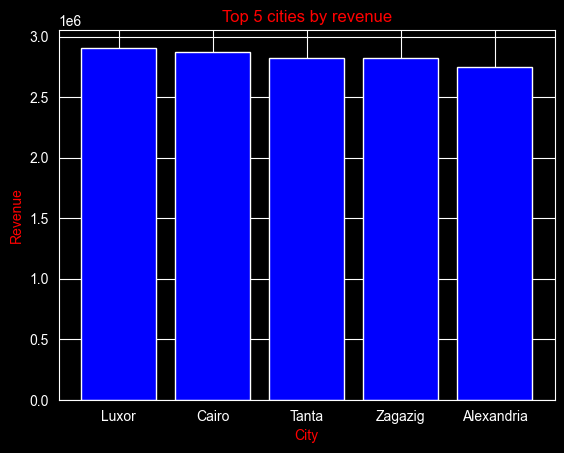

In [38]:
plt.bar(city_r.index,city_r.values,color="b")
plt.title("Top 5 cities by revenue",color="red")
plt.xlabel("City",color="red")
plt.ylabel("Revenue",color="red")
plt.show()

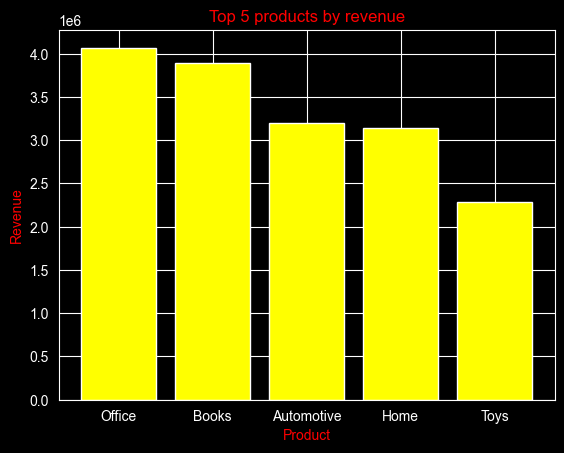

In [13]:
plt.bar(prod_r.index,prod_r.values,color="yellow")
plt.title("Top 5 products by revenue",color="red")
plt.xlabel("Product",color="red")
plt.ylabel("Revenue",color="red")
plt.show()

In [14]:
df = df.dropna(subset=["unit_price"]).copy()

df["city"] = df["city"].fillna("Unknown")
df["payment_method"] = df["payment_method"].fillna("Unknown")

In [15]:
df.isna().sum()

order_id                         0
customer_id                      0
order_date                       0
city                             0
gender                         497
acquisition_channel              0
device                         100
payment_method                   0
shipping_method                  0
shipping_fee                     0
tax_rate                         0
order_status                     0
product_id                       0
product_category                 0
product_brand                    0
unit_price                       0
quantity                         0
discount_amount                  0
coupon_code                  12815
line_subtotal                    0
line_net                         0
order_items                      0
order_gross                      0
order_discount                   0
order_net_before_tax_ship        0
order_tax                        0
order_total                      0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(201)

In [17]:
df = df.drop_duplicates().copy()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
(df["quantity"] <= 0).sum()

np.int64(50)

In [20]:
df = df[df["quantity"] > 0].copy()

In [21]:
(df["quantity"] <= 0).sum()

np.int64(0)

In [22]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 17692 entries, 0 to 18021
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   order_id                   17692 non-null  str           
 1   customer_id                17692 non-null  str           
 2   order_date                 17692 non-null  datetime64[us]
 3   city                       17692 non-null  str           
 4   gender                     17205 non-null  str           
 5   acquisition_channel        17692 non-null  str           
 6   device                     17595 non-null  str           
 7   payment_method             17692 non-null  str           
 8   shipping_method            17692 non-null  str           
 9   shipping_fee               17692 non-null  int64         
 10  tax_rate                   17692 non-null  float64       
 11  order_status               17692 non-null  str           
 12  product_id          

In [24]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

In [25]:
import os

os.makedirs("outputs", exist_ok=True)

In [48]:
df.to_csv("outputs/clean_data_week2.csv", index=False)
df.to_csv("mustafa work file.csv",index=False)

In [27]:
orders_level["order_date"] = pd.to_datetime(orders_level["order_date"])
orders_level["month"] = orders_level["order_date"].dt.month
orders_level["year"] = orders_level["order_date"].dt.year

In [28]:
orders_level["month"]

order_id
O0000001    1
O0000002    1
O0000003    1
O0000004    1
O0000005    1
           ..
O0005996    2
O0005997    2
O0005998    2
O0005999    2
O0006000    2
Name: month, Length: 6000, dtype: int32

In [29]:
orders_level["year"]

order_id
O0000001    2024
O0000002    2024
O0000003    2024
O0000004    2024
O0000005    2024
            ... 
O0005996    2026
O0005997    2026
O0005998    2026
O0005999    2026
O0006000    2026
Name: year, Length: 6000, dtype: int32

In [30]:
monthly_revenue = (orders_level.groupby(["year", "month"])["order_total"].sum().sort_index())

monthly_revenue.head()

year  month
2024  1        1080665.81
      2        1059659.52
      3        1195915.64
      4        1287524.89
      5        1354226.60
Name: order_total, dtype: float64

In [31]:
df.groupby("order_id").first().shape[0]

5986

In [32]:
qty_per_order = df.groupby("order_id")["quantity"].first().head()


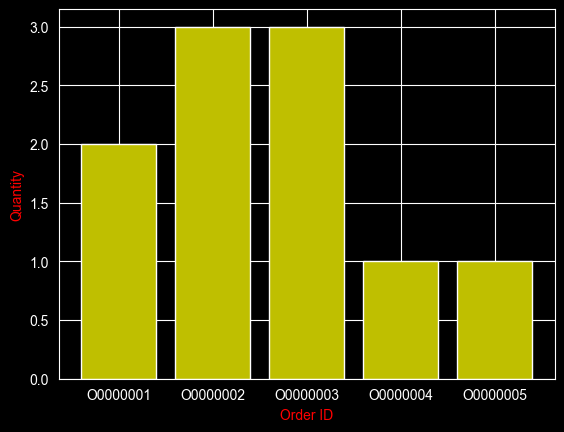

In [33]:
plt.bar(qty_per_order.index,qty_per_order.values,color="y")
plt.xlabel("Order ID",color="r")
plt.ylabel("Quantity",color="r")
plt.show()

In [34]:
monthly_orders = (orders_level.groupby(["year", "month"]).size().sort_index())

monthly_orders.head()

year  month
2024  1        225
      2        232
      3        241
      4        235
      5        259
dtype: int64

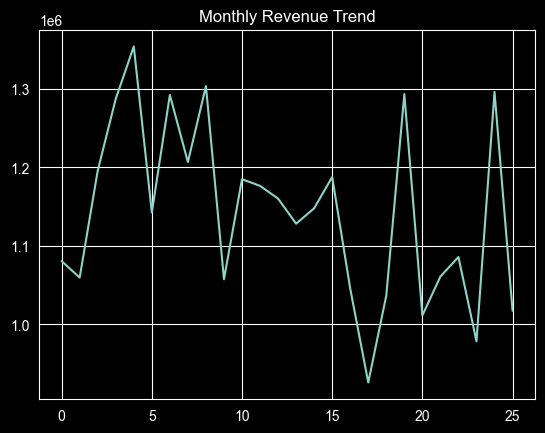

In [35]:
plt.plot(monthly_revenue.values)
plt.title("Monthly Revenue Trend")
plt.show()

In [36]:
monthly_revenue.idxmax()
monthly_revenue.idxmin()

(np.int32(2025), np.int32(6))